<a href="https://colab.research.google.com/github/s326327/Days-1---5-Data-Science/blob/main/Lesson5_What_Is_Normal_and_Surprising%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Index(['year', 'mean_temp_max_f'], dtype='object')
(85, 2)
   year  mean_temp_max_f    zscore
0  1940        74.860164 -1.529066
1  1941        73.588384 -2.210000
2  1942        74.747781 -1.589238
3  1943        77.564658 -0.081031
4  1944        77.513934 -0.108190


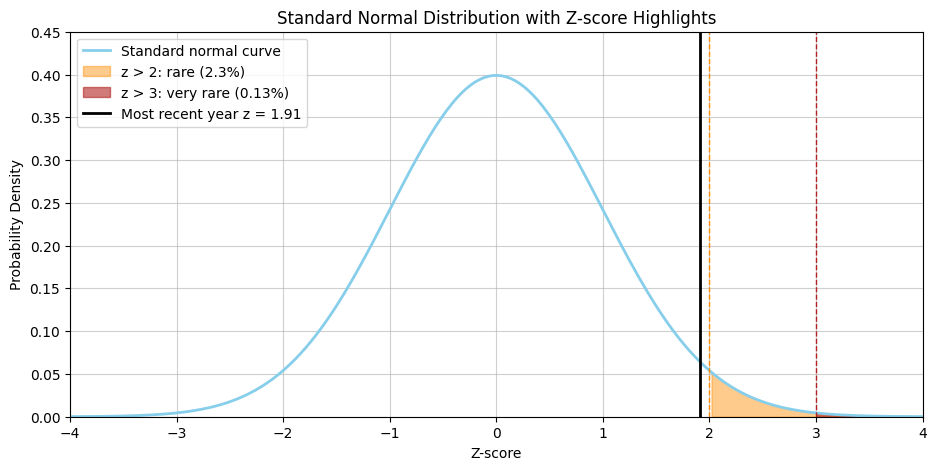

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

baseline_mean = 77.7160
baseline_std = 1.8677

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load the annual summary data. The DataFrame 'df' already contains 'year' and 'mean_temp_max_f'.
annual = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')
df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')

# Display the columns to confirm the available data
print(df.columns)

print(annual.shape)

annual['zscore'] = (annual['mean_temp_max_f'] - baseline_mean) / baseline_std

print(annual[['year', 'mean_temp_max_f', 'zscore']].head())


x = np.linspace(-4, 4, 300)
y = stats.norm.pdf(x)
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, y, color='skyblue', linewidth=2, label='Standard normal curve')
ax.fill_between(x, y, where=(x >= 2), color='darkorange', alpha=0.45, label='z > 2: rare (2.3%)')
ax.fill_between(x, y, where=(x >= 3), color='firebrick', alpha=0.6, label='z > 3: very rare (0.13%)')
ax.axvline(2, color='darkorange', linestyle='--', linewidth=1)
ax.axvline(3, color='firebrick', linestyle='--', linewidth=1)
recent_z = annual.iloc[-1]['zscore']
ax.axvline(recent_z, color='black', linestyle='-', linewidth=2, label=f'Most recent year z = {recent_z:.2f}')

ax.set_title('Standard Normal Distribution with Z-score Highlights') # Added title
ax.set_xlabel('Z-score') # Set x-axis label
ax.set_ylabel('Probability Density') # Set y-axis label
ax.set_xlim(-4, 4)
ax.set_ylim(0, 0.45) # Set explicit y-axis limit
ax.grid(alpha=0.6) # Increased grid visibility
ax.legend(loc='upper left')

In [ ]:
print('Years, Z-scores, and Mean Maximum Temperatures:')
display(annual[['year', 'zscore', 'mean_temp_max_f']])

Years, Z-scores, and Mean Maximum Temperatures:


,year,zscore,mean_temp_max_f
0,1940,-1.529066,74.860164
1,1941,-2.210000,73.588384
2,1942,-1.589238,74.747781
3,1943,-0.081031,77.564658
4,1944,-0.108190,77.513934
...,...,...,...
80,2020,1.372460,80.279344
81,2021,0.296812,78.270356
82,2022,1.481039,80.482137
83,2023,1.977438,81.409260


In [ ]:
import json

# Create the dictionary with the specified data, explicitly converting numpy types to native Python types
json_data = {
    'baseline_mean': float(baseline_mean),
    'baseline_std': float(baseline_std),
    'most_recent_year': int(annual.iloc[-1]['year']),
    'most_recent_zscore': float(annual.iloc[-1]['zscore']),
    'highest_zscore': float(annual['zscore'].max()),
    'year_of_highest_zscore': int(annual.loc[annual['zscore'].idxmax(), 'year'])
}

# Define the filename for the JSON file
json_filename = 'Austin_Z-score_Summary.json'

# Write the dictionary to a JSON file
with open(json_filename, 'w') as f:
    json.dump(json_data, f, indent=4)

print(f'JSON data saved to {json_filename}')

JSON data saved to Austin_Z-score_Summary.json
